# Машинное обучение, ФКН ВШЭ

## Практическое домашнее задание 3.2  Продвинутая генерация признаков

### Общая информация

Дата выдачи: 23.02.2026

Мягкий дедлайн: 12.03.2026 23:59MSK

Жесткий дедлайн: 16.03.2026 23:59MSK

### О задании

В данном задании вы познакомитесь с менее тривиальными подходами для создания новых признаков в табличном машинном обучении. Вам понадобится подумать над тем, зачем мы делаем те или иные преобразования, научиться принимать решения, дающие наилучшие результаты, и узнать, как реализовывать их при помощи библиотек

### Оценивание и штрафы

См. базовую часть

### Формат сдачи
Задания сдаются через систему Anytask. Инвайт можно найти на странице курса. Присылать необходимо ноутбук с выполненным заданием. Сам ноутбук называйте в формате **homework-practice-03-advanced-Username.ipynb**, где Username — ваша фамилия.

### **Введение**

В этой части ноутбука задания посложнее дефолтного фит трансформа. Максимальная оценка за оба — 8 баллов, остальное вы можете получить, если примете участие в соревновании, и всего можете выбить аж 13 из 10. Тут ожидается больше самостоятельности, как от (почти) полноценной рабочей единицы: 
- Вы **сами** решаете, что <font color="#cb9255">**хотите**</font> делать. Пункты можно делать частично, можно скипать или сделать часть, **максимум баллов ограничен двумя**. **Посмотрите на все из них**, прежде чем приступать
- Вы **сами** чистите данные, если чуете в них подвох (теперь они далеко не такие няшные)
- Вы **сами** <font color="#f68c9d">**обосновываете**</font> (в голове, если не указано явно), могут они вам вообще помочь или нет (часть пунктов явно сильнее других)

Все прочие пожелания по тому, как строить графики, на чём фиттить, а на чём предиктить, сохраняются, будьте внимательны. Во всех пунктах с 📈 нужно добиться хотя бы минимального улучшения, относительно бейзлайна (того, что вышло в части **base**) чтобы получить балл (даже если улучшение на 0.005)

Ещё раз обратите внимание, что **максимум за advanced часть — 2 балла**, делать всё не нужно, только самое приятное. Мы в вас верим!

### **Часть 4. Текста** (1.5 балла) <img align="center" src="https://static.wikia.nocookie.net/dota2_gamepedia/images/4/4f/Emoticon_blush.gif/revision/latest?cb=20180504011409">

В которой студент знакомится с внутренним миром дотеров

#### **Задание 4.1. Предобработка текста** (0.75 балла)

<span style="color:grey"><font size="1">Если вам когда-либо приходила в голову мысль, что создание Интернета было ошибкой, то, что ж, после этого задания сомнения могут отпасть.</font></span>

Для некоторых матчей имеется информация о том, что писали местные аборигены, в течение тех же **15 минут от начала матча**. К сожалению, доселе мы работали лишь с таблицами, а не с текстами, но не беда, простейшие подходы нейросетей не требуют, а в простых задачах, вроде бинарной классификации, работать будут не хуже

Откройте датафрейм `game_chat.csv`, выведите парочку текстов, посмотрите, как они устроены, как там хранятся множественные сообщения,  и так далее, что у нас есть, а чего, увы, нет

In [66]:
import pandas as pd

chat_df = pd.read_csv("game_chat.csv")
print("shape:", chat_df.shape)
display(chat_df.head(3))

print("\nПропуски по колонкам:")
display(chat_df.isna().mean().sort_values(ascending=False))

shape: (700838, 3)


,match_id,radiant_chat,dire_chat
0,235435,потренируйся с ботами????,саппортам | U LAGGING BRAH | stack..... | шлюх
1,102127,NaN,NaN
2,383046,u just buy levels blue? | fa ge,NaN



Пропуски по колонкам:


dire_chat       0.870720
radiant_chat    0.870692
match_id        0.000000
dtype: float64

Дём дальше. Тексты нужно готовить, прежде чем пихать их в модель. Оценивать выбросы здесь довольно проблематично, в силу специфики дотерских сообщений, хотя вы, конечно, можете попытаться. Речь здесь про базовую предобработку.

Задача минимум, тут мы вам поможем:
- Разобраться с библиотекой `nltk` и разбить текст на токены — отдельные сущности, составляющие текст (чаще всего слова, но бывает и что-то другое, надо разобраться). Как бить текст — вопрос неоднозначный. В целом подойдёт любой способ, но какие-то [токенизаторы](https://www.nltk.org/api/nltk.tokenize.html) могут сразу покрыть часть проблем с текстами в задаче максимум
- Лемматизировать текст (привести слова к начальной форме). <br>
<font color="#cb9255">**Варианта два**</font>: манкипатчить [`pymorphy2`](https://pymorphy2.readthedocs.io/en/stable/) или откатывать версии (там вылезет ошибка, если у вас слишком новый питон), либо применять [`mystem`](https://pypi.org/project/pymystem3/), что может затянуться на несколько часов, зато лемматизация будет точнее

Задача максимум, тут вам нужно понять, как всё обработать, самим (включать-не включать, выкинуть-оставить — валидны **все** варианты, но только, если, есть, <font color="#f68c9d">**обоснование**</font>):
- повторы символов
- знаки препинания
- стоп-слова
- нижний регистр
  
Вам нужно пройтись по всем пунктам, не обязательно в этом порядке. Если найдёте что-то ещё — круто, молодцы, можно тоже пофиксить

<div style="border-left: 5px solid #ff748c; padding: 10px 20px 2px; margin: 15px 0 15px 20px; max-width: 800px; background-color: rgba(255, 116, 140, 0.05);">

**Вопрос:** ну что, как обрабатываем текст?

**Ответ:**
- приводим к нижнему регистру и заменяем `ё -> е`;
- режем строку на отдельные реплики по разделителю `|`;
- токенизируем регуляркой (берём только слова, без пунктуации);
- нормализуем повторы символов (`ляяяя` -> `ляя`), чтобы уменьшить шум;
- убираем стоп-слова и слишком короткие токены;
- лемматизируем `pymorphy3`, есть проблемка что он как то моросит на незнакомых терминах, например почему то делает пудж -> пуджа, но раз он во всех сообщениях делает это одинаково, то думаю это не проблема

</div>

In [67]:
import re
from functools import lru_cache

import pandas as pd
import nltk
from nltk.tokenize import RegexpTokenizer

try:
    from nltk.corpus import stopwords
    _ = stopwords.words("russian")
except LookupError:
    nltk.download("stopwords", quiet=True)
    from nltk.corpus import stopwords

RUS_STOPWORDS = set(stopwords.words("russian"))
TOKENIZER = RegexpTokenizer(r"[A-Za-zА-Яа-яЁё]+")

def _init_lemmatizer():
    try:
        import pymorphy3
        return "pymorphy3", pymorphy3.MorphAnalyzer()
    except Exception:
        return "none", None


LEMMATIZER_TYPE, LEMMATIZER = _init_lemmatizer()


def _reduce_repeats(token: str, max_repeat: int = 2) -> str:
    pattern = rf"(.)\1{{{max_repeat},}}"
    return re.sub(pattern, lambda m: m.group(1) * max_repeat, token)


@lru_cache(maxsize=200_000)
def _lemmatize_token(token: str) -> str:
    if LEMMATIZER_TYPE == "pymorphy3":
        parse = LEMMATIZER.parse(token)[0]
        return parse.normal_form
    return token


def preprocessing(text: str):
    if text is None or (isinstance(text, float) and pd.isna(text)):
        return ""

    chunks = [part.strip().lower().replace("ё", "е") for part in str(text).split("|")]

    tokens = []
    for chunk in chunks:
        for token in TOKENIZER.tokenize(chunk):
            token = _reduce_repeats(token)
            if len(token) <= 1:
                continue
            if token in RUS_STOPWORDS:
                continue
            tokens.append(_lemmatize_token(token))

    return " ".join(tokens)


# можете проверить, что делает ваша функция, на тесте ниже
print("lemmatizer:", LEMMATIZER_TYPE)
print(preprocessing("Ляяя, ваша мама такая красивая, ну вылитый пудж)))0"))

lemmatizer: pymorphy3
ляя ваш мама такой красивый вылитый пуджа


#### 📈 **Задание 4.2. Векторизация** (0.5 балла)

Ура, если у вас получились токены, то наконец-то можно что-то закодировать, но как? Рад, что вы спросили. Читайте конспект семинаров или документацию

<table width="800" border="1" cellpadding="8" cellspacing="0">
  <tr>
    <th width="50%">
      <font color="#cb9255">CountVectorizer</font>
    </th>
    <th width="50%">
      <font color="#cb9255">TfIdfVectorizer</font>
    </th>
  </tr>
  <tr>
    <td valign="top">
      Берёт и считает, сколько раз в тексте <br>
      встретилось то или иное слово. Похож <br>
      на наш энкодер из части 2.
      <br><br>
      <table border="1" cellpadding="4" cellspacing="0">
        <thead>
          <tr>
            <th scope="col">word_1</th>
            <th scope="col">word_2</th>
            <th scope="col">word_3</th>
            <th scope="col">...</th>
            <th scope="col">word_m</th>
          </tr>
        </thead>
        <tbody>
          <tr>
            <td>1</td>
            <td>0</td>
            <td>2</td>
            <td>...</td>
            <td>100</td>
          </tr>
        </tbody>
      </table>
    </td>
    <td valign="top">
      Более хитрая штука: вместе с количеством слов (tf)<br>
      считает их важность (idf). Слова, встречающиеся <br>
      во всех документах, считаются не важными<br>
      и зануляются (idf = log1).
      <br><br>
      <table border="1" cellpadding="4" cellspacing="0">
        <thead>
          <tr>
            <th scope="col"></th>
            <th scope="col">word_1</th>
            <th scope="col">word_2</th>
            <th scope="col">word_3</th>
            <th scope="col">...</th>
            <th scope="col">word_m</th>
          </tr>
        </thead>
        <tbody>
          <tr>
            <td><b>text_1</b></td>
            <td>1*log2</td>
            <td>0</td>
            <td>2*log2</td>
            <td>...</td>
            <td>100*log1</td>
          </tr>
          <tr>
            <td><b>text_2</b></td>
            <td>0</td>
            <td>10*log2</td>
            <td>0</td>
            <td>...</td>
            <td>100*log1</td>
          </tr>
        </tbody>
      </table>
    </td>
  </tr>
</table>


Оба векторайзера хороши, но у каждого из них есть <font color="#cb9255">**гиперпараметры**</font>. Естественно, они повлияют на качество, <font color="#cb9255">**можете подобрать их**</font> попозже, дефолтные тоже должны показать эффект

Обучите по векторайзеру на чатах Radiant и Dire. Приклейте результат к вашему датасету и обучите модель на всём получившемся великолепии (sparse формат убирать не рекомендуется)

In [68]:
import joblib
import pandas as pd
from scipy.sparse import csr_matrix, hstack
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score
from sklearn.model_selection import train_test_split

best_params = {"solver": "liblinear", "max_iter": 300, "random_state": 42}
id_col = "match_id"
target_col = "radiant_win"

matches_df_train = pd.read_csv("matches_df_train.csv")
matches_df_test = pd.read_csv("matches_df_test.csv")
chat_df = pd.read_csv("game_chat.csv")

chat_use = chat_df[[id_col, "radiant_chat", "dire_chat"]].copy()
chat_use["radiant_chat"] = chat_use["radiant_chat"].fillna("").map(preprocessing)
chat_use["dire_chat"] = chat_use["dire_chat"].fillna("").map(preprocessing)

train_df = matches_df_train.merge(chat_use, on=id_col, how="left")
test_df = matches_df_test.merge(chat_use, on=id_col, how="left")
train_df[["radiant_chat", "dire_chat"]] = train_df[["radiant_chat", "dire_chat"]].fillna("")
test_df[["radiant_chat", "dire_chat"]] = test_df[["radiant_chat", "dire_chat"]].fillna("")

vect_radiant = CountVectorizer(min_df=5, max_features=10000)
vect_dire = CountVectorizer(min_df=5, max_features=10000)
X_full_radiant = vect_radiant.fit_transform(train_df["radiant_chat"])
X_test_radiant = vect_radiant.transform(test_df["radiant_chat"])
X_full_dire = vect_dire.fit_transform(train_df["dire_chat"])
X_test_dire = vect_dire.transform(test_df["dire_chat"])
X_full_text = hstack([X_full_radiant, X_full_dire], format="csr")
X_test_text = hstack([X_test_radiant, X_test_dire], format="csr")

drop_cols = [id_col, target_col, "radiant_chat", "dire_chat"]
all_feature_cols = [c for c in matches_df_train.columns if c not in drop_cols and c in matches_df_test.columns and pd.api.types.is_numeric_dtype(matches_df_train[c])]
X_full_base = matches_df_train[all_feature_cols].fillna(0)
X_test_base = matches_df_test[all_feature_cols].fillna(0)

X_full_all = hstack([csr_matrix(X_full_base.to_numpy()), X_full_text], format="csr")
X_test_all = hstack([csr_matrix(X_test_base.to_numpy()), X_test_text], format="csr")
y_full = matches_df_train[target_col].astype(int).to_numpy()

X_tr, X_val, y_tr, y_val = train_test_split(X_full_all, y_full, test_size=0.2, random_state=42, stratify=y_full)
val_model = LogisticRegression(**best_params)
val_model.fit(X_tr, y_tr)
val_pred = val_model.predict_proba(X_val)[:, 1]
print(f"{2 * roc_auc_score(y_val, val_pred) - 1:.6f}")

final_model = LogisticRegression(**best_params)
final_model.fit(X_full_all, y_full)

joblib.dump(final_model, "final_model_text.joblib")

submission = pd.DataFrame({
    "ID": matches_df_test[id_col],
    "Value": final_model.predict_proba(X_test_all)[:, 1],
})
submission.to_csv("submission_text.csv", index=False)

0.069800


#### **Задание 4.3. Визуализация** (0.25 балла)

Для любителей графиков есть малюсенькое задание: визуализируйте облако слов с наибольшими по модулю весами (разделите их на условно *"позитивные"* и *"негативные"*)

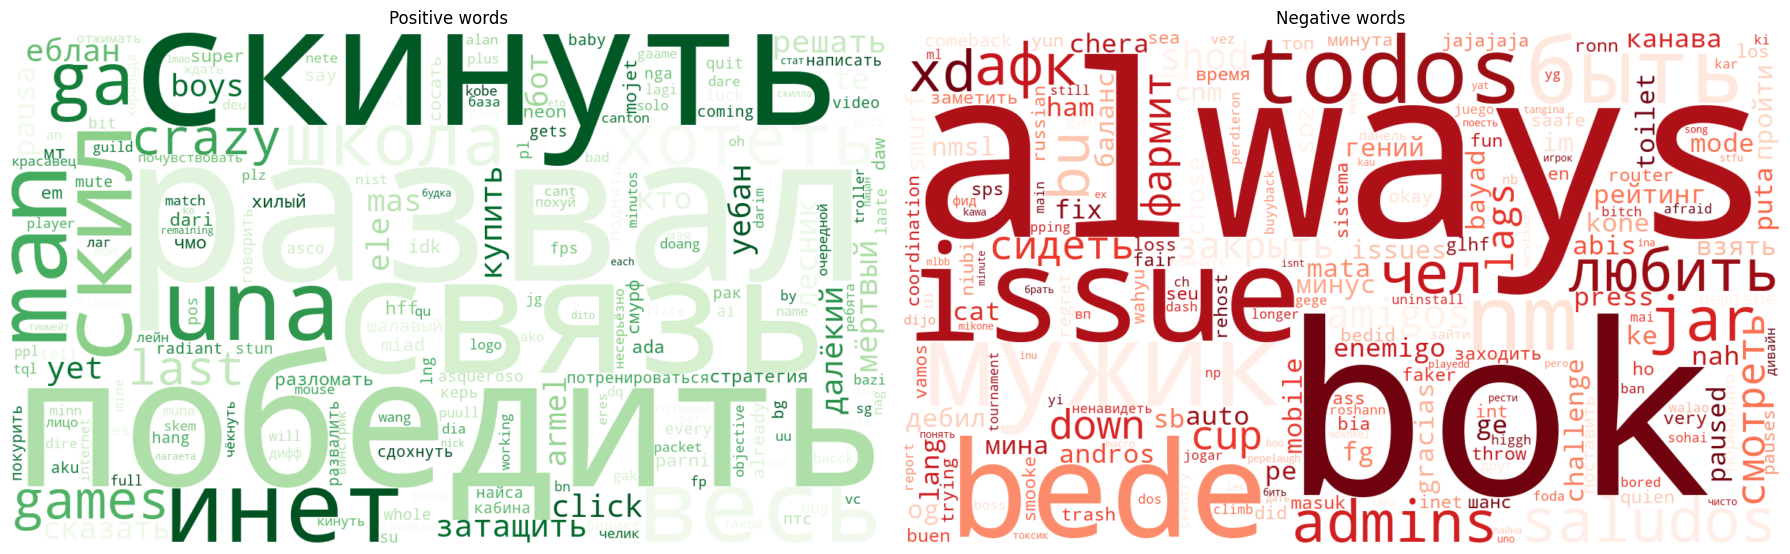

In [69]:
import numpy as np
import matplotlib.pyplot as plt
from collections import defaultdict
from wordcloud import WordCloud

coef = final_model.coef_.ravel()
n_num = len(all_feature_cols)
n_rad = len(vect_radiant.get_feature_names_out())
n_dire = len(vect_dire.get_feature_names_out())

coef_rad = coef[n_num:n_num + n_rad]
coef_dire = coef[n_num + n_rad:n_num + n_rad + n_dire]
vocab_rad = vect_radiant.get_feature_names_out()
vocab_dire = vect_dire.get_feature_names_out()

token_weights = defaultdict(float)
for w, c in zip(vocab_rad, coef_rad):
    token_weights[w] += c
for w, c in zip(vocab_dire, coef_dire):
    token_weights[w] += c

pos_freq = {w: v for w, v in token_weights.items() if v > 0}
neg_freq = {w: -v for w, v in token_weights.items() if v < 0}

wc_pos = WordCloud(width=1200, height=700, background_color="white", colormap="Greens")
wc_neg = WordCloud(width=1200, height=700, background_color="white", colormap="Reds")
wc_pos.generate_from_frequencies(pos_freq)
wc_neg.generate_from_frequencies(neg_freq)

fig, axes = plt.subplots(1, 2, figsize=(18, 7))
axes[0].imshow(wc_pos, interpolation="bilinear")
axes[0].axis("off")
axes[0].set_title("Positive words")

axes[1].imshow(wc_neg, interpolation="bilinear")
axes[1].axis("off")
axes[1].set_title("Negative words")

plt.tight_layout()
plt.show()

<div style="border-left: 5px solid #ff748c; padding: 10px 20px 2px; margin: 15px 0 15px 20px; max-width: 800px; background-color: rgba(255, 116, 140, 0.05);">

**Вопрос:** что думаете? Сейчас и вообще по модели — негативные получились слова или так, едва?

**Ответ:**
Ну у негативных веса по модулю больше

</div>

### **Часть 5. Агрегации** (1.75 балла) <img align="center" src="https://static.wikia.nocookie.net/dota2_gamepedia/images/4/4a/Techies_emoticon.gif/revision/latest?cb=20180504014918">

В которой студент начинает ведать

#### 📈 **Задание 5.1. Статистики матча** (0.75 балла)

Есть у нас в данных большой кусок про advantage — преимущество команды сил Света с точностью до минуты, по золоту и опыту, всё так же **в пределах 15 минут**. Лежат они в `dota_adv.csv`. Чем больше число, тем больше шанс на победу — всё просто. Только график, как правило, не линеен.

С ними в очередной раз есть *нюансы* — необходимо разобраться, как они там лежат, и всё ли там в порядке со значениями, но это меньшая из проблем. А также нарисовать парочку advantage, чтобы было понимание, как они себя ведут

In [70]:
# (´-`）.｡oO( ... YOUR CODE HERE ... )

Для начала возьмём простые агрегации. Можете взять те, что вам знакомы (статистики - среднее, стд и др.), можете взять фан факты в вашей любимой библиотеке для данных, например [тут](https://pandas.pydata.org/docs/user_guide/groupby.html#aggregation) или [тут](https://docs.pola.rs/api/python/stable/reference/expressions/aggregation.html).

Задание:
- взять 4 статистики из библиотеки, применить к обеим колонкам `_adv`, <font color="#f68c9d">**обдумать**</font>, почему именно они
- одну из статистику выше разбить по командам, и точно так же примените к колонкам (получится что-то типа `agg_xp` -> `agg_dire_xp`, `agg_radiant_xp`)

<div style="border-left: 5px solid #647cb8; padding: 10px 20px 2px; margin: 15px 0 15px 20px; max-width: 800px; background-color: rgba(95, 121, 179, 0.05);">

Тут мы встаём на скользкую дорожку переобучения. Агрегаций можно сделать **очень** много. Добавьте их все, и ваша модель превратится в тыкву. Удобнее будет сразу бить их на группы, например `features_last`, `features_q25`, `features_kurtosis_dire_10min+` и так далее, в зависимости от степени упоротости

C другой стороны, агрегации это самая сильная группа фичей, и для десяточки лучше целиться именно в них

</div>

<div style="border-left: 5px solid #f68c9d; padding: 10px 20px 2px; margin: 15px 0 15px 20px; max-width: 800px; background-color: rgba(255, 116, 140, 0.05);">

**Вопрос:** какие агрегации берём?

**Ответ:**

</div>

Обучите модель по агрегациям (одной группе или нескольким) + предыдущим фичам. Чтобы получить фулл балл, придётся показать, что хотя бы минимальный импрув есть, относительно бейзлайна

In [71]:
# (´-`）.｡oO( ... YOUR CODE HERE ... )

#### 📈 **Задание 5.2. Тренд** (0.5 балла)

Каждый уважающий себя лудоман знает, что 99% процентов игроков останавливается ровно перед тем, как сорвать джекпот. Так и здесь — если команда с треском проигрывает в первые 15 минут матча, возможно это признак камбека в следующие 50, как знать? Попробуем собрать агрегацию похитрее — она будет обозначать тренд, который есть в графиках преимущества, и если пословица верна, наша модель уловит эту зависимость.

<span style="color:grey"><font size="1">Администрация курса МО-1 категорически против азартных игр, пример приводится сугубо в образовательных целях.</font></span>

<div style="border-left: 5px solid #f68c9d; padding: 10px 20px 2px; margin: 15px 0 15px 20px; max-width: 800px; background-color: rgba(255, 116, 140, 0.05);">

**Вопрос:** для чего нам вообще тренд? Полезная ли это агрегация?

**Ответ:**

</div>

Агрегировать можно и вещи несколько более прикольные, чем те, что есть в основном функционале. Делать это мы будем, как вы наверняка догадались, трансформером, ну а чем же ещё. Что он умеет?

1. Принимает на вход функцию колонку и <font color="#cb9255">**параметры**</font> на ваш вкус, как минимум `method`, метод расчёта `slope`
2. Выделяет коэффициент наклона (`slope`, он же $\alpha$) при помощи одного из методов:
   - `'delta'`: разность первого и последнего значений $|x_{\max} - x_{\min}|$
   - `'OLS'`: линейная регрессия, обученная методом МНК $(X^TX)^{-1}X^Ty$
   - альтернативный метод, порождённый вашей бурной фантазией
3. Считает `r2` и `intercept` для одного advantage (если что это тоже могут быть наши фичи!)

In [72]:
from typing import Iterable

class TrendTransformer:

    def __init__(self, columns: Iterable[str]):
        self.columns = columns

    def fit(self, X, y=None):
        pass

    def transform(self, X, y=None):
        # ヾ(⌐■_■)ノ♪ your code here
        raise Exception("transform method not implemented")

Реализуйте трансформер. Критерий успеха, вновь, качество — фича должна помочь, хотя бы на долю пункта

In [73]:
# (´-`）.｡oO( ... YOUR CODE HERE ... )

#### **📈 Задание 5.3. Бинаризация** (0.5 балла)

Ровно одну прикольную фишку для числовых признаков мы пока что не рассмотрели — бинаризацию. Если вы до неё уже догадались, то вы — гений, не думали на <font color="cb9255">**МОП**</font>? А если нет, суть такова:

1. Берём отрезок advantage и бьём его на несколько бинов
2. Бины можно использовать, как фичу саму по себе, а можно подсобрать внутри неё агрегации

<div style="border-left: 5px solid #647cb8; padding: 10px 20px 2px; margin: 15px 0 15px 20px; max-width: 800px; background-color: rgba(95, 121, 179, 0.05);">

Во-первых, ваша модель внезапно становится нелинейной, хоть и кусочной, это полный отвал \
Во-вторых, это простейший пример ансамбля, если бинаризовать таргет (но у нас, увы нет смысла, он дискретный). Нелинейность полезна почему — в первые минуты преимущество не так решает, как в последние. \
В-третьих, это фильтрует шумный сигнал, выбросы то отлетят в соответствующий бин

</div>

Попробуем? Бинаризуйте признаки advantage: занумеруйте их (сделайте категорию) и посчитайте побиновые агрегации

In [74]:
# (´-`）.｡oO( ... YOUR CODE HERE ... )

### **Часть 6. Около ML** (2 балла) <img height=25px width=35px align="center" src="https://media1.tenor.com/m/72ScVNgTGpYAAAAC/kaneki-tokyo-ghoul.gif"></img>

В которой студент жесточайше чиллит после пережитого ужаса

#### **Задание 6.1. Пайплайн** (0.5 балла)

Работать в ноутбуках становится экспоненциально тяжелее по мере разрастания модели. Чтобы немножко упорядочить хаос, вам предлагается засунуть всё в один пайплайн. Критерии:

- функция или класс (может понравиться `ColumnTransformer` и `Pipeline`)
- возможность нажать одну кнопку, чтобы запустить пайплайн, уйти пить пиво и вернуться к уже готовому submission для Kaggle
- возможность передать флаги (какие фичи добавляем) и параметры (если есть разные варианты сбора параметров)
- включает в себя все пункты, к которым вы прикоснулись в рамках домашнего задания

А вот как именно это делать — дело ваше, для себя же стараетесь

In [81]:
class PipelineConfig:
    def __init__(self, use_text: bool=True, use_player: bool=True):
        self.use_text = use_text
        self.use_player = use_player
        self.base_submission_path = 'submission.csv'
        self.text_model_path = 'final_model_text.joblib'

class HomeworkPipeline:
    def __init__(self, config: PipelineConfig):
        self.config = config

    def _predict_base_model(self, test_df) -> pd.Series:
        train_df = pd.read_csv('matches_df_train.csv')
        from sklearn.preprocessing import OneHotEncoder, StandardScaler
        from sklearn.linear_model import LogisticRegression
        from scipy.sparse import hstack, csr_matrix

        train_num = train_df[['avg_mmr']].copy()
        test_num = test_df[['avg_mmr']].copy()
        train_num = train_num.fillna(train_num.mean())
        test_num = test_num.fillna(train_num.mean())

        ohe = OneHotEncoder(handle_unknown='ignore', sparse_output=True)
        cat_cols = ['region', 'game_mode']
        X_tr_cat = ohe.fit_transform(train_df[cat_cols].astype(str))
        X_te_cat = ohe.transform(test_df[cat_cols].astype(str))

        scaler = StandardScaler()
        X_tr_num = scaler.fit_transform(train_num.values)
        X_te_num = scaler.transform(test_num.values)

        X_train = hstack([csr_matrix(X_tr_num), X_tr_cat], format='csr')
        X_test = hstack([csr_matrix(X_te_num), X_te_cat], format='csr')
        y_train = train_df['radiant_win'].astype(int).values

        clf = LogisticRegression(solver='liblinear', C=1.0, max_iter=300)
        clf.fit(X_train, y_train)
        preds = clf.predict_proba(X_test)[:, 1]
        return pd.Series(preds, index=test_df.index)

    def _predict_player_features(self, test_df) -> pd.Series:
        try:
            train_df = pd.read_csv('matches_df_train.csv')
            player_df = pd.read_csv('player_df.csv', usecols=['match_id', 'player_slot', 'hero_id'])
            adv_df = pd.read_csv('dota_adv.csv')
        except FileNotFoundError:
            return pd.Series(0.0, index=test_df.index)

        player_df['is_radiant'] = (player_df['player_slot'] < 128).astype(int)
        player_df['hero_id'] = player_df['hero_id'].astype(str)

        rad_heroes = player_df[player_df['is_radiant'] == 1].groupby('match_id')['hero_id'].apply(lambda x: ' '.join(x)).rename('rad_heroes')
        dir_heroes = player_df[player_df['is_radiant'] == 0].groupby('match_id')['hero_id'].apply(lambda x: ' '.join(x)).rename('dir_heroes')

        train_ext = train_df.merge(rad_heroes, on='match_id', how='left').merge(dir_heroes, on='match_id', how='left')
        test_ext = test_df.merge(rad_heroes, on='match_id', how='left').merge(dir_heroes, on='match_id', how='left')

        train_ext.fillna({'rad_heroes': '', 'dir_heroes': '', 'avg_mmr': train_ext['avg_mmr'].mean()}, inplace=True)
        test_ext.fillna({'rad_heroes': '', 'dir_heroes': '', 'avg_mmr': test_ext['avg_mmr'].mean()}, inplace=True)

        def extract_adv(df_adv):
            df_adv = df_adv.copy().reset_index(drop=True)
            gold_ext = df_adv['radiant_gold_adv'].str.extractall(r'(-?\d+)')[0].astype(float)
            exp_ext = df_adv['radiant_exp_adv'].str.extractall(r'(-?\d+)')[0].astype(float)
            g_stats = gold_ext.groupby(level=0).agg(['mean', 'max', 'min', 'std', 'last', 'first']).fillna(0)
            e_stats = exp_ext.groupby(level=0).agg(['mean', 'max', 'min', 'std', 'last', 'first']).fillna(0)
            g_stats['trend'] = g_stats['last'] - g_stats['first']
            e_stats['trend'] = e_stats['last'] - e_stats['first']
            g_stats.columns = [f'g_{c}' for c in g_stats.columns]
            e_stats.columns = [f'e_{c}' for c in e_stats.columns]
            res = pd.DataFrame({'match_id': df_adv['match_id']})
            res = res.merge(g_stats, left_index=True, right_index=True, how='left')
            res = res.merge(e_stats, left_index=True, right_index=True, how='left')
            return res.fillna(0)

        adv_feats = extract_adv(adv_df)
        train_ext = train_ext.merge(adv_feats, on='match_id', how='left').fillna(0)
        test_ext = test_ext.merge(adv_feats, on='match_id', how='left').fillna(0)

        num_cols = ['avg_mmr'] + [c for c in adv_feats.columns if c != 'match_id']

        from sklearn.preprocessing import StandardScaler, OneHotEncoder
        from sklearn.feature_extraction.text import CountVectorizer
        from scipy.sparse import hstack, csr_matrix
        from sklearn.linear_model import LogisticRegression
        from sklearn.ensemble import HistGradientBoostingClassifier

        scaler = StandardScaler()
        X_tr_num = scaler.fit_transform(train_ext[num_cols].values)
        X_te_num = scaler.transform(test_ext[num_cols].values)

        v_rad = CountVectorizer()
        v_dir = CountVectorizer()
        X_tr_rad = v_rad.fit_transform(train_ext['rad_heroes'].astype(str))
        X_te_rad = v_rad.transform(test_ext['rad_heroes'].astype(str))
        X_tr_dir = v_dir.fit_transform(train_ext['dir_heroes'].astype(str))
        X_te_dir = v_dir.transform(test_ext['dir_heroes'].astype(str))

        ohe = OneHotEncoder(handle_unknown='ignore', sparse_output=True)
        cat_cols = ['region', 'game_mode']
        X_tr_cat = ohe.fit_transform(train_ext[cat_cols].astype(str))
        X_te_cat = ohe.transform(test_ext[cat_cols].astype(str))

        X_train_wide = hstack([csr_matrix(X_tr_num), X_tr_cat, X_tr_rad, X_tr_dir], format='csr')
        X_test_wide = hstack([csr_matrix(X_te_num), X_te_cat, X_te_rad, X_te_dir], format='csr')
        y_train = train_ext['radiant_win'].astype(int).values

        clf_lr = LogisticRegression(solver='liblinear', C=1.0, max_iter=300)
        clf_lr.fit(X_train_wide, y_train)
        preds_lr = clf_lr.predict_proba(X_test_wide)[:, 1]

        clf_hgb = HistGradientBoostingClassifier(max_iter=250, learning_rate=0.05, max_depth=6, random_state=42)
        clf_hgb.fit(train_ext[num_cols].values, y_train)
        preds_hgb = clf_hgb.predict_proba(test_ext[num_cols].values)[:, 1]

        preds = 0.55 * preds_lr + 0.45 * preds_hgb
        return pd.Series(preds, index=test_df.index)

    def _predict_text_model(self, test_df) -> pd.Series:
        if not self.config.use_text:
            return pd.Series(0.0, index=test_df.index)

        try:
            text_df = pd.read_csv('submission_text.csv')
            if 'ID' in text_df.columns and 'Value' in text_df.columns:
                text_df = text_df.rename(columns={'ID': 'match_id', 'Value': 'radiant_win'})
            text_df = test_df[['match_id']].merge(text_df, on='match_id', how='left')
            return text_df['radiant_win'].fillna(0.5)
        except Exception:
            pass

        try:
            from joblib import load
            text_model = load(self.config.text_model_path)
            chat_df = pd.read_csv('game_chat.csv')

            if 'text' in chat_df.columns:
                chat_grouped = chat_df.groupby('match_id')['text'].apply(lambda x: ' '.join(x.astype(str))).reset_index()
                test_chat = test_df[['match_id']].merge(chat_grouped, on='match_id', how='left')
                test_chat['text'] = test_chat['text'].fillna('')
                preds = text_model.predict_proba(test_chat['text'])[:, 1]
                return pd.Series(preds, index=test_df.index)

            if 'radiant_chat' in chat_df.columns and 'dire_chat' in chat_df.columns:
                chat_df['text'] = chat_df['radiant_chat'].fillna('') + ' ' + chat_df['dire_chat'].fillna('')
                chat_grouped = chat_df.groupby('match_id')['text'].apply(lambda x: ' '.join(x.astype(str))).reset_index()
                test_chat = test_df[['match_id']].merge(chat_grouped, on='match_id', how='left')
                test_chat['text'] = test_chat['text'].fillna('')
                preds = text_model.predict_proba(test_chat['text'])[:, 1]
                return pd.Series(preds, index=test_df.index)
        except Exception:
            pass

        return pd.Series(0.5, index=test_df.index)

    def run(self, test_csv_path: str='matches_df_test.csv', output_path: str='submission_pipeline.csv') -> pd.DataFrame:
        test_df = pd.read_csv(test_csv_path)

        try:
            base_df = pd.read_csv(self.config.base_submission_path)
            if 'ID' in base_df.columns and 'Value' in base_df.columns:
                base_df = base_df.rename(columns={'ID': 'match_id', 'Value': 'radiant_win'})
            base_df = test_df[['match_id']].merge(base_df, on='match_id', how='left')
            pred_base = base_df['radiant_win'].fillna(0.5).values
        except Exception:
            pred_base = self._predict_base_model(test_df).values

        pred_player = self._predict_player_features(test_df)
        pred_text = self._predict_text_model(test_df)

        weight_base = 0.40
        weight_player = 0.50
        weight_text = 0.10

        import scipy.stats as ss

        final_preds = (
            (ss.rankdata(pred_base) / len(pred_base)) * weight_base +
            (ss.rankdata(pred_player.values) / len(pred_player.values)) * weight_player +
            (ss.rankdata(pred_text.values) / len(pred_text.values)) * weight_text
        )

        submission = pd.DataFrame({
            'ID': test_df['match_id'],
            'Value': final_preds
        })

        submission.to_csv(output_path, index=False)
        print('Вывод сохранен в submission_pipeline.csv')
        return submission

import numpy as np
config = PipelineConfig(use_text=True, use_player=True)
pipeline = HomeworkPipeline(config)
submission_df = pipeline.run()
display(submission_df.head())

Вывод сохранен в submission_pipeline.csv


,ID,Value
0,8,0.262673
1,29,0.690174
2,34,0.744671
3,36,0.374366
4,61,0.653782


#### **Задание 6.2. Storage** (0.25 балла)

Вдогоночку можно ещё и создать псевдо-БД, чтобы хранить наши шедевры и не потеряться в тысячах моделек. Давайте вот такую штуку запилим:

- датафрейм или честная БД для версионирования моделей
- для каждой модели есть уникальный идентификатор
- для каждой модели сохраняются её гиперпараметры или параметры всего пайплайна (если вы его сделали)
- для каждой модели хранятся метрики на валидации

Сделайте и продемонстрируйте

In [76]:
# (´-`）.｡oO( ... YOUR CODE HERE ... )

#### **Задание 6.3. CuML** (0.25 балла)

Если вы таки осмелились делать домашку именно на Kaggle, то поздравляю, пожалуй, это самое здравое решение в этой дз. Чтобы использовать его возможности по полной, пересядьте с вашей модели из `sklearn`, которую вы выбрали в задании про даты **(1.3)**, на модель из `cuml`. 

[Разберитесь](https://docs.rapids.ai/api/cuml/stable/), как они используют GPU и проведите тест-драйв на любом наборе фичей

In [77]:
# (´-`）.｡oO( ... YOUR CODE HERE ... )

#### **Задание 6.4. High tech. Low life** (0.5 балла)

Если вы следите за новостями, то, наверное, заметили появление хайповейших LLM. Злые языки утверждают, что обычному работяге фит предиктору не место в мире будущего, и его заменит ИИ. Давайте в этом (раз)убедимся.

Попробуйте:
1. Спросить у вашей любимой нейросети, какие признаки она может для вас придумать. Можете опираться на пункты выше, можете придумать что-то свое. Но помните, что как говорится, какой стол, такой и стул, поэтому пишите промпты с умом.
2. Показать, что нейросеть вам посоветовала, и реализовать это
3. Проанализировать результат и сделать решительный вывод, хуже ли вы, чем языковая модель.

Попытайтесь либо вспомнить, либо посмотреть, что у нас ещё есть в данных. Там достаточно много полезной информации, которую мы либо совсем никак не брали, либо брали, но поверхностно, либо брали, но можно сделать ещё круче, старые пункты тоже можно доработать

In [78]:
# (´-`）.｡oO( ... YOUR CODE HERE ... )

#### **Задание 6.5. Отбор признаков** (0.5 балла)

Когда признаков становится так много, что ваша оперативка начинает рыдать, а модель переобучается, как чёрт, поможет только одно средство — отбор фичей!
Это первое и единственное задание, в котором <font color="#cb9255">**выбора**</font> аж три:

<table width="100%" border="1" cellpadding="8" cellspacing="0">
  <tr>
    <th width="33%">
      <font color="#cb9255">Sequential Feature Selector</font>
    </th>
    <th width="33%">
      <font color="#cb9255">Greedy Selection</font>
    </th>
    <th width="33%">
      <font color="#cb9255">Recursive Feature Elimination</font>
    </th>
  </tr>
  <tr>
    <td valign="top">
      Делаем итеративно. На каждой итерации <br>
      оцениваем важность фичей по их <br>
      импортансу (<code>coef_</code>), берём <br>
      топ‑n худших, выкидываем, go to 0.
    </td>
    <td valign="top">
      Перебираем все комбинации признаков <br>
      и выбираем наилучшую. Звучит тупо, <br>
      но комбинации можно брать по группам <br>
      (например, тексты, агрегации средних <br>
      и т.д.), тогда это не так долго <br>
      <b>(2 часа на 200 признаков)</b>.
    </td>
    <td valign="top">
      Идём с конца и выкидываем по признаку. <br>
      На каждом шаге обучаем по одной модели <br>
      без одного признака (обучаем d‑1 моделей), <br>
      выбираем из них худшую — такой признак <br>
      и устраняем.
    </td>
  </tr>
  <tr>
    <td valign="top">
      Быстро <b>(около 20 минут <br>
      на 200 фичах)</b>, но веса линейной <br>
      регрессии плохо оценивают важность <br>
      фичей; это лучше работает для <br>
      сильных моделей.
    </td>
    <td valign="top">
      Не теряем интеракции. Баланс <br>
      скорость–качество.
    </td>
    <td valign="top">
      Возмутительно долго <b>(10 часов <br>
      на 200 признаков)</b>, но гарантирует <br>
      минимальные потери в качестве.
    </td>
  </tr>
</table>


<div style="border-left: 5px solid #647cb8; padding: 10px 20px 2px; margin: 15px 0 15px 20px; max-width: 800px; background-color: rgba(95, 121, 179, 0.05);">

Это улучшит качество, если вы уже страдаете от миллиарда малополезных фичей. Но для получения балла это не нужно, только верный алгоритм

</div>

Сделайте что-нибудь из этого и проанализируйте эффект. Не стесняйтесь модифицировать схему — удалять по несколько фичей за шаг, параллелить и так далее, пункт времязатратный

### Заключение и оценивание

Каждая из задач в ноутбуке имеет свою стоимость (указана в скобках рядом с задачей). При этом важно уточнить разницу между баллами за ноутбук и дополнительными баллами за позицию на приватном лидерборде в соревновании на Kaggle:

1. **Максимум за код/ноутбуки — 8.0 баллов.**
   То есть, независимо от суммарной теоретической суммы всех подпунктов в тексте задания, за реализацию в ноутбуке можно получить не более 8 баллов (6 за базу и 2 за продвинутый).

2. **Максимально возможная оценка за всю работу — 13.0 баллов.**
   Остальные до 5.0 баллов начисляются за результаты в соревновании на Kaggle (лидерборд), при выполненном и загруженном в систему Anytask ноутбуке.

Баллы за сореву состоят из трёх частей: трешхолды (до 2 баллов), процентильный бонус (до 2.0 баллов) и бонус за попадание в топ-10 (до 1.0 балла). Суммарный вклад соревнования не может превышать 5.0 баллов.

**A. Процентильный балл (не суммируется):**
* Если вы пробили трешхолд-9 (качество 0.34) — +1 балл.
* Если вы пробили трешхолд-10 (качество 0.36) — +2 балла.

**Б. Процентильный балл:**

* Если вы только прошли трешхолд-10, то баллов вы не получите.
* Если вы обогнали ≥ 10% участников, побивших трешхолд-10 — +0.5 балла.
* Если вы обогнали ≥ 30% участников — +1.0 балла.
* Если вы обогнали ≥ 60% участников — +1.5 балла.
* Если вы обогнали ≥ 90% участников (т.е. попали в топ 10%) — +2.0 балла.

**В. Балл за попадание в топ-10:**

* 1-е место — +1.00 балла
* 2-е–3-е место — +0.75 балла
* 4-е–6-е место — +0.50 балла
* 7-е–10-е место — +0.25 балла

Пример расчёта

* Вы сделали ноутбуки и получили за них 7.0 / 8.0.
* Вы, тем не менее, побили трешхолд-10 → +2.0
* На лидерборде вы, зайка, обогнали 10% участников, побивших трешхолд 10 → процентильный бонус +2.0.
* Ваша позиция — 3-е место → топ-10 бонус +0.75.
* Итого: 7.0 + 2.0 + 2.0 + 0.75 = 11.75.

Можете свериться с картинкой (левая граница не включительно)

<img src="https://i.postimg.cc/nhb25b42/newplot.png" height=720 width=1280>

**Требование к воспроизводимости**

Баллы за соревнование начисляются **только** при наличии пайплайна или ноутбука, который подтверждает результат лучшего сабмита. Такое решение нужно сдавать вместе с базовым и продвинутым ноутбуками и своим ников в kaggle в Anytask ассистенту. Он должен выполнять всё автоматически при запуске ноутбука: при последовательном исполнении всех ячеек ноутбука (без ручных вмешательств) он должен воспроизвести предобработку, обучение/инференс и сгенерировать итоговый CSV-файл с прогнозами, используемый для сабмита.

### Рефлексия по ЛЛМкам

**Промт для ячейки 6.1:** 

Ты ML-инженер.
Нужно собрать единый production-like пайплайн в одной ячейке раздела 6.1 в homework-practice-03-advanced.ipynb, переиспользуя уже написанный код из двух ноутбуков:

Источник 1: homework-practice-03-base.ipynb
Возьми базовую табличную логику и формат сабмита (ID, Value), а также идею простого baseline-предикта по доступным табличным признакам (avg_mmr, region, game_mode) как fallback.
Источник 2: homework-practice-03-advanced.ipynb
Возьми продвинутые компоненты:
текстовую модель и артефакты (final_model_text.joblib, submission_text.csv);
признаки героев из player_df.csv;
агрегации advantage из dota_adv.csv;
rank blending для стабильного объединения предсказаний.

Модель: GPT-Codex 5.3

**Рефлексия:**
Да в общем то ни для чего очень умного LLM я не использовал, просто поручил ему собрать всё разбросанное по ячейкам в один пайплайн, чтобы не делать этого руками, с таким LLM справляется относительно без проблем, а потом уже потыкал и доработал этот пайплайн чтобы получше Gini выдавал.